## Sequential Decomposition Algorithm for Open-Pit Mine Scheduling Problem Including Blending

### Installing packages

In [1]:
!pip install -q pandas==2.2.3 numpy==2.2.5 plotly==6.0.1 mip==1.17.6 gurobipy==13.0.1 PyMaxFlow==1.3.2 "pyvista[jupyter]"==0.47.3 

### Importing packages

In [2]:
import time, pandas as pd, numpy as np, gurobipy as gp, maxflow, plotly.express as px, matplotlib.pyplot as plt, pyvista as pv
from mip import *

### Gurobi Licence

In [3]:
params = {"WLSACCESSID": '6d07e162-8371-471b-b8a0-e6ab21d8d81d', "WLSSECRET": '596d61af-4797-43dd-a681-165e023e3d7f',
"LICENSEID":2502611,'OutputFlag': 0}

### Loading block model file

In [4]:
# Load block model
cols = ["id", "x", "y", "z", "tonn", "au", "cu", "profit_proc"] # Load block model 
blocks = pd.read_csv("marvin.blocks", sep=r"\s+", header=None, names=cols, engine="python") # Read the block model (space-separated format)
blocks["blockvalue"] = blocks["tonn"] * np.where(blocks["profit_proc"] > 0, blocks["profit_proc"] - 0.9, -0.9)
blocks["destination"] = (blocks["profit_proc"] > 0).astype(int) # Determine destination based on copper grade
blocks["upit"] = pd.NA # Add a column to store the upit (initially empty)
blocks["period"] = pd.NA # Add a column to store the extraction period (initially empty)
print(f"Loaded {len(blocks):,} blocks")

Loaded 53,271 blocks


### Loading block precedences file

In [7]:
# Load precedence relations (Precedence file format: block_id  n_prec  prec1  prec2  ... )
precedence = {}
with open("marvin.prec") as f:
    for line in f:
        parts = line.strip().split()
        block_id = int(parts[0])
        n_prec = int(parts[1])
        precedence[block_id] = [int(parts[k]) for k in range(2, 2+n_prec)]
print(f"Loaded {sum(len(precs) for precs in precedence.values()):,} precedences")

Loaded 650,631 precedences


## UPIT - Mathematical Programming

In [8]:
ids = blocks["id"].astype(int).tolist()
B = list(range(len(ids))); id_to_b = {ids[b]: b for b in B}
v = blocks["blockvalue"].tolist()

try: Model(sense=MAXIMIZE, solver_name="GRB").clear(); solver_name = "GRB"
except: solver_name = "CBC"

t0 = time.time()
model = Model(sense=MAXIMIZE, solver_name=solver_name)
x = [model.add_var(var_type=BINARY) for _ in B]
model.objective = xsum(v[b] * x[b] for b in B)

for bid, precs in precedence.items():                              # precedence constraints
    if bid not in id_to_b: continue
    for prec in precs:
        model += (x[id_to_b[bid]] <= x[id_to_b[prec]]) if prec in id_to_b else (x[id_to_b[bid]] == 0)

model.optimize()
selected = [ids[b] for b in B if x[b].x >= 0.99]
blocks["upit"] = blocks["id"].isin(selected).astype(int)
print(f"UPIT value: {model.objective_value:,.0f} | Blocks: {len(selected)} | Time: {time.time()-t0:.2f}s")
blocks.to_csv("marvin_upit.csv", index=False); print("Saved: marvin_upit.csv")

UPIT value: 1,415,655,436 | Blocks: 8516 | Time: 20.06s
Saved: marvin_upit.csv


In [9]:
dx, dy, dz = 30, 30, 30
xmin, ymin, zmin = blocks["x"].min(), blocks["y"].min(), blocks["z"].min()
nx = int((blocks["x"]-xmin).max())+1; ny = int((blocks["y"]-ymin).max())+1; nz = int((blocks["z"]-zmin).max())+1

def vox(df):
    g = np.zeros((nx,ny,nz), dtype=np.uint8)
    g[(df["x"]-xmin).astype(int).to_numpy(), (df["y"]-ymin).astype(int).to_numpy(), (df["z"]-zmin).astype(int).to_numpy()] = 1
    u = pv.ImageData(); u.dimensions = np.array(g.shape)+1; u.spacing = (dx,dy,dz); u.cell_data["occ"] = g.flatten(order="F")
    return u.threshold(0.5)

mesh_in  = vox(blocks[blocks["upit"]==1])                          # pit blocks
mesh_out = vox(blocks[blocks["upit"]==0])                          # waste blocks

pl = pv.Plotter()
a_in  = pl.add_mesh(mesh_in,  color="gold", show_edges=True, edge_color="black", opacity=1.0)
a_out = pl.add_mesh(mesh_out, color="gray", show_edges=False, opacity=0.3)
pl.add_axes(viewport=(0.75,0.0,1.0,0.25))
pl.add_checkbox_button_widget(lambda v: a_in.SetVisibility(v),  value=True, position=(10,50), size=25, color_on="gold", color_off="white")
pl.add_text("Extracted blocks",     position=(45,52), font_size=10)
pl.add_checkbox_button_widget(lambda v: a_out.SetVisibility(v), value=True, position=(10,90), size=25, color_on="gray", color_off="white")
pl.add_text("Non-extracted blocks", position=(45,92), font_size=10)
pl.view_isometric(); pl.export_html("marvin_upit.html"); pl.show()

Widget(value='<iframe src="http://localhost:50907/index.html?ui=P_0x200e95ad5d0_0&reconnect=auto" class="pyvis…

## UPIT - Pseudoflow

In [10]:
# UPIT via Maximum Closure (max-flow / min-cut)
t0 = time.time()
n, vals = len(blocks), blocks["blockvalue"].to_numpy()
id2i = {bid: b for b, bid in enumerate(blocks["id"].values)}
pos_sum = float(vals[vals > 0].sum()); INF = pos_sum + 1.0
g = maxflow.Graph[float](); nodes = g.add_nodes(n)
for b, v in enumerate(vals):                                       # source/sink edges
    g.add_tedge(nodes[b], v, 0.0) if v >= 0 else g.add_tedge(nodes[b], 0.0, -v)
for bid, preds in precedence.items():                              # precedence arcs
    bi = id2i.get(bid)
    if bi is not None:
        for pid in preds:
            pi = id2i.get(pid)
            if pi is not None: g.add_edge(nodes[bi], nodes[pi], INF, 0.0)
flow = g.maxflow()                                                 # solve
blocks["upit_pf"] = [1 if g.get_segment(nodes[i]) == 0 else 0 for i in range(n)]
upit_value = pos_sum - flow
print(f"UPIT value: {upit_value:,.0f}  |  Time: {(time.time()-t0):.2f} s")

blocks.to_csv("marvin_UPIT_Pseudoflow.csv", index=False)
print("Saved: marvin_UPIT_Pseudoflow.csv")

UPIT value: 1,415,655,436  |  Time: 0.50 s
Saved: marvin_UPIT_Pseudoflow.csv


In [11]:
dx, dy, dz = 30, 30, 30
xmin, ymin, zmin = blocks["x"].min(), blocks["y"].min(), blocks["z"].min()
nx = int((blocks["x"]-xmin).max())+1; ny = int((blocks["y"]-ymin).max())+1; nz = int((blocks["z"]-zmin).max())+1

def vox(df):
    g = np.zeros((nx,ny,nz), dtype=np.uint8)
    g[(df["x"]-xmin).astype(int).to_numpy(), (df["y"]-ymin).astype(int).to_numpy(), (df["z"]-zmin).astype(int).to_numpy()] = 1
    u = pv.ImageData(); u.dimensions = np.array(g.shape)+1; u.spacing = (dx,dy,dz); u.cell_data["occ"] = g.flatten(order="F")
    return u.threshold(0.5)

mesh_in  = vox(blocks[blocks["upit_pf"]==1])                          # pit blocks
mesh_out = vox(blocks[blocks["upit_pf"]==0])                          # waste blocks

pl = pv.Plotter()
a_in  = pl.add_mesh(mesh_in,  color="gold", show_edges=True, edge_color="black", opacity=1.0)
a_out = pl.add_mesh(mesh_out, color="gray", show_edges=False, opacity=0.3)
pl.add_axes(viewport=(0.75,0.0,1.0,0.25))
pl.add_checkbox_button_widget(lambda v: a_in.SetVisibility(v),  value=True, position=(10,50), size=25, color_on="gold", color_off="white")
pl.add_text("Extracted blocks",     position=(45,52), font_size=10)
pl.add_checkbox_button_widget(lambda v: a_out.SetVisibility(v), value=True, position=(10,90), size=25, color_on="gray", color_off="white")
pl.add_text("Non-extracted blocks", position=(45,92), font_size=10)
pl.view_isometric(); pl.export_html("marvin_upit_pseudoflow.html"); pl.show()

Widget(value='<iframe src="http://localhost:50907/index.html?ui=P_0x200944ef790_1&reconnect=auto" class="pyvis…

### Sequential Algorithm for Open-Pit Mine Scheduling

In [12]:
# Parameters 
max_period = 16       # Maximum number of scheduling periods
PC = 20_000_000        # Processing capacity (tons)
MC = 60_000_000        # Mine capacity (tons)
alpha = 0.10           # Discount rate for Net Present Value (NPV)

# Sequential Optimization 
code_start = time.time()
period_profit = []   # Store discounted values per period
extracted = set()    # Keep track of already extracted blocks

# Build a model using Gurobi Solver, if available, or use open-source CBC solver (MIP Package Default)
try:
    Model(sense=MAXIMIZE, solver_name="GRB").clear()
    solver_name = "GRB"
except Exception:
    solver_name = "CBC"
print(f"Using {solver_name} solver")
print("Starting optimization")

# Loop over scheduling periods
for t in range(max_period):

    # Available blocks = those not extracted yet
    B = list(blocks.index[(blocks["upit_pf"] == 1) & (~blocks["id"].isin(extracted))])
    if not B:
        break  # Stop if no available blocks remain

    # Extract data for available blocks
    ids = blocks.loc[B, "id"].tolist()
    d = blocks.loc[B, "destination"].tolist()
    v = blocks.loc[B, "blockvalue"].tolist()
    w = blocks.loc[B, "tonn"].tolist()

    model = Model(sense=MAXIMIZE, solver_name=solver_name)
        
    # Allow 5% optimality gap
    model.max_mip_gap = 0.05   

    # Decision variables: x[i] = 1 if block i is extracted in this period
    x = [model.add_var(var_type=BINARY) for _ in B]

    # Objective: maximize undiscounted profit in this period
    model.objective = xsum(x[b] * v[b] for b in range(len(B)))

    # Precedence constraints: a block can only be extracted if its predecessors are extracted
    id_to_var = {ids[b]: b for b in range(len(B))}
    for bid in ids:
        if bid in precedence:
            for prec in precedence[bid]:
                if prec in extracted:
                    continue  # Already extracted in earlier period
                elif prec in id_to_var:
                    model += x[id_to_var[prec]] >= x[id_to_var[bid]]
                else:
                    # Predecessor not extracted yet → force this block = 0
                    if blocks.loc[blocks["id"] == prec, "upit_pf"].values[0] == 1: # Se predecessor está fora do UPIT, ignora (não é minerável)
                        model += x[id_to_var[bid]] == 0
                    
    # Capacity constraint (only processing blocks where destination=1)
    model += xsum(d[b] * w[b] * x[b] for b in range(len(B))) <= PC
    model += xsum(w[b] * x[b] for b in range(len(B))) <= MC

    # Solve optimization 
    opt_start = time.time()
    model.optimize()
    opt_time = time.time() - opt_start

    # Check solution status
    if model.status == OptimizationStatus.OPTIMAL and model.objective_value > 0:
        undiscounted_value = model.objective_value
        discounted_value = undiscounted_value / ((1 + alpha) ** t)
        period_profit.append(discounted_value)

        # Update extracted blocks
        files_start = time.time()
        selected = []
        for b, var in enumerate(x):
            if var.x > 0.5:  # If block is selected
                bid = ids[b]
                extracted.add(bid)
                blocks.loc[blocks["id"] == bid, "period"] = t
                selected.append(bid)
        files_time = time.time() - files_start

        # Print summary for this period
        print(f"Period: {t} | "
              f"Undiscounted: {undiscounted_value:,.0f} | " f"Discounted: {discounted_value:,.0f} | " f"Blocks: {len(selected)} | "
              f"Opt Time (min): {opt_time/60:.2f} | " f"Files Time (min): {files_time/60:.2f}")
    else:
        break

    # Clear model (free memory before next period)
    model.clear()

# Final Results 
npv = sum(period_profit)  # Net Present Value
print(f"\nNPV: {npv:,.0f}")
print(f"Total blocks extracted: {len(extracted)}")
print(f"Code Time: {(time.time()-code_start)/60:.2f} minutes")

# Save solution 
blocks.to_csv("marvin_schedule.csv", index=False)

Using GRB solver
Starting optimization
Period: 0 | Undiscounted: 95,361,606 | Discounted: 95,361,606 | Blocks: 416 | Opt Time (min): 0.61 | Files Time (min): 0.01
Period: 1 | Undiscounted: 108,926,942 | Discounted: 99,024,492 | Blocks: 369 | Opt Time (min): 0.68 | Files Time (min): 0.00
Period: 2 | Undiscounted: 116,835,220 | Discounted: 96,558,033 | Blocks: 412 | Opt Time (min): 0.14 | Files Time (min): 0.01
Period: 3 | Undiscounted: 123,902,937 | Discounted: 93,090,111 | Blocks: 344 | Opt Time (min): 0.08 | Files Time (min): 0.00
Period: 4 | Undiscounted: 123,563,872 | Discounted: 84,395,787 | Blocks: 396 | Opt Time (min): 0.14 | Files Time (min): 0.00
Period: 5 | Undiscounted: 119,260,382 | Discounted: 74,051,314 | Blocks: 464 | Opt Time (min): 0.08 | Files Time (min): 0.01
Period: 6 | Undiscounted: 115,987,133 | Discounted: 65,471,713 | Blocks: 465 | Opt Time (min): 0.06 | Files Time (min): 0.01
Period: 7 | Undiscounted: 109,917,512 | Discounted: 56,405,064 | Blocks: 490 | Opt Time

### 3D Plot

In [13]:
dx,dy,dz=30,30,30  # block size

df_w=blocks.loc[blocks.period.isna(),["x","y","z"]]  # waste
df_e=blocks.loc[blocks.period.notna(),["x","y","z","period"]].copy(); df_e.loc[:,"period"]=df_e.period.astype(int)  # extracted
P=sorted(df_e.period.unique())  # periods asc

df_w.loc[:,["x","y","z"]]*=[dx,dy,dz]; df_e.loc[:,["x","y","z"]]*=[dx,dy,dz]  # scale

xmin,ymin,zmin=(blocks[["x","y","z"]].min()*[dx,dy,dz]); xmax,ymax,zmax=(blocks[["x","y","z"]].max()*[dx,dy,dz])  # bounds
nx,ny,nz=int((xmax-xmin)/dx)+1,int((ymax-ymin)/dy)+1,int((zmax-zmin)/dz)+1  # grid

meshes={}
if not df_w.empty:
    ix=((df_w.x-xmin)/dx).astype(int); iy=((df_w.y-ymin)/dy).astype(int); iz=((df_w.z-zmin)/dz).astype(int)  # idx
    g=np.zeros((nx,ny,nz),np.uint8); g[ix,iy,iz]=1  # grid
    img=pv.ImageData(dimensions=np.array(g.shape)+1,spacing=(dx,dy,dz),origin=(xmin,ymin,zmin)); img.cell_data["occ"]=g.flatten(order="F"); meshes["w"]=img.threshold(0.5)  # mesh

for p in P:
    d=df_e.loc[df_e.period==p]  # slice
    if d.empty: continue
    ix=((d.x-xmin)/dx).astype(int); iy=((d.y-ymin)/dy).astype(int); iz=((d.z-zmin)/dz).astype(int)
    g=np.zeros((nx,ny,nz),np.uint8); g[ix,iy,iz]=1
    img=pv.ImageData(dimensions=np.array(g.shape)+1,spacing=(dx,dy,dz),origin=(xmin,ymin,zmin)); img.cell_data["occ"]=g.flatten(order="F"); meshes[f"P{p}"]=img.threshold(0.5)

pl=pv.Plotter(); A={}
if "w" in meshes: A["w"]=pl.add_mesh(meshes["w"],color="lightgray",opacity=0.15)  # waste

c = list(plt.colormaps["tab20"].colors) + list(plt.colormaps["tab20b"].colors) + list(plt.colormaps["tab20c"].colors)
#c=[plt.cm.nipy_spectral(i/len(P)) for i in range(len(P))]
for i,p in enumerate(P): A[f"P{p}"]=pl.add_mesh(meshes[f"P{p}"],color=c[i%len(c)],show_edges=True,edge_color="black")  # periods

labels=[f"P{p}" for p in P]+(["w"] if "w" in A else [])  # order
y0,dyb,n=40,28,len(labels)

for i,k in enumerate(labels):
    a=A[k]; col="lightgray" if k=="w" else c[int(k[1:])%len(c)]; txt="Waste" if k=="w" else f"Period {int(k[1:])}"; y=y0+(n-1-i)*dyb  # invert Y
    pl.add_checkbox_button_widget(callback=lambda v,a=a:a.SetVisibility(v), value=True, position=(10,y), size=22, color_on=col, color_off="white", border_size=2)
    pl.add_text(txt, position=(40,y+3), font_size=10)

pl.add_axes(viewport=(0.78,0.02,0.98,0.22)); pl.view_isometric(); pl.reset_camera(); pl.camera.zoom(1.15)  # view
pl.export_html("marvin_plot.html"); pl.show()  # output

Widget(value='<iframe src="http://localhost:50907/index.html?ui=P_0x200ae1b2710_2&reconnect=auto" class="pyvis…

### Capacity & Grade Chart

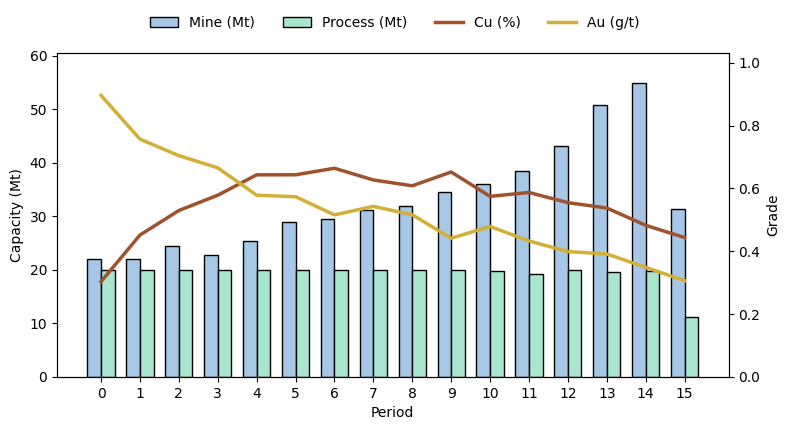

In [14]:
df=blocks.dropna(subset=["period"]).copy()  # extracted

summary=(df.assign(w_proc=df.tonn*df.destination, cu_proc=lambda d:d.cu*d.w_proc, au_proc=lambda d:d.au*d.w_proc)
           .groupby("period",as_index=False)
           .agg(ton_mine=("tonn","sum"), ton_plant=("w_proc","sum"), cu_metal=("cu_proc","sum"), au_metal=("au_proc","sum")))

summary[["cu_grade","au_grade"]]=summary[["cu_metal","au_metal"]].div(summary["ton_plant"],axis=0).fillna(0)

x=np.arange(len(summary)); w=0.35
fig,ax1=plt.subplots(figsize=(8,4))

ax1.bar(x-w/2,summary.ton_mine/1e6,w,label="Mine (Mt)",color="#A7C7E7",edgecolor="black"); ax1.bar(x+w/2,summary.ton_plant/1e6,w,label="Process (Mt)",color="#A8E6CF",edgecolor="black")
ax1.set(xlabel="Period",ylabel="Capacity (Mt)",xticks=x,xticklabels=summary.period.astype(int),ylim=(0,1.1*max(summary.ton_mine.max(),summary.ton_plant.max())/1e6))

ax2=ax1.twinx()
ax2.plot(x,summary.cu_grade,color="#A0522D",lw=2.5,label="Cu (%)"); ax2.plot(x,summary.au_grade,color="#D4AF37",lw=2.5,label="Au (g/t)")
ax2.set(ylabel="Grade",ylim=(0,1.15*max(summary.cu_grade.max(),summary.au_grade.max())))

ax1.patch.set_visible(False)

h,l=zip(*[ax.get_legend_handles_labels() for ax in (ax1,ax2)]); h=sum(h,[]); l=sum(l,[])
fig.legend(h,l,loc="upper center",ncol=4,bbox_to_anchor=(0.5,1.08),frameon=False)

plt.tight_layout(); fig.savefig("marvin_results.png",dpi=300,bbox_inches="tight",facecolor="white"); plt.show()

### Sequential Algorithm for Open-Pit Mine Scheduling Including Blend

In [18]:
# Parâmetros
max_period = 16        # Maximum number of scheduling periods
PC = 20_000_000        # Processing capacity (tons)
MC = 60_000_000        # Mine capacity (tons)
alpha = 0.10           # Discount rate for Net Present Value (NPV)

# Restrições de teor
g_target = 0.45        # teor alvo
g_min    = 0.35        # teor mínimo
g_max    = 0.55        # teor máximo

# Penalização por desvio do alvo
PENALTY = 1_000_000

# Sequential Optimization
code_start = time.time()
period_profit = []     # Store discounted values per period
extracted = set()      # Keep track of already extracted blocks

# reseta os períodos do caso anterior
blocks["period"] = pd.NA

# Build a model using Gurobi Solver, if available, or use open-source CBC solver
try:
    Model(sense=MAXIMIZE, solver_name="GRB").clear()
    solver_name = "GRB"
except Exception:
    solver_name = "CBC"

print(f"Using {solver_name} solver")
print("Starting optimization")

# Loop over scheduling periods
for t in range(max_period):

    # Available blocks = those not extracted yet
    B = list(blocks.index[(blocks["upit_pf"] == 1) & (~blocks["id"].isin(extracted))])
    if not B:
        break  # Stop if no available blocks remain

    # Extract data for available blocks
    ids = blocks.loc[B, "id"].tolist()
    d   = blocks.loc[B, "destination"].tolist()
    v   = blocks.loc[B, "blockvalue"].tolist()
    w   = blocks.loc[B, "tonn"].tolist()
    g   = blocks.loc[B, "cu"].tolist()   # teor de cobre

    model = Model(sense=MAXIMIZE, solver_name=solver_name)
    model.max_mip_gap = 0.05

    # Decision variables: x[i] = 1 if block i is extracted in this period
    x = [model.add_var(var_type=BINARY) for _ in B]

    # Variáveis de desvio em relação ao teor alvo
    delta_plus  = model.add_var(var_type=CONTINUOUS, lb=0)
    delta_minus = model.add_var(var_type=CONTINUOUS, lb=0)

    # Expressões lineares
    total_ore = xsum(d[b] * w[b] * x[b] for b in range(len(B)))           # minério enviado à planta
    total_mine = xsum(w[b] * x[b] for b in range(len(B)))                 # total lavrado
    metal = xsum(g[b] * d[b] * w[b] * x[b] for b in range(len(B)))        # metal contido no minério processado

    # Objective: maximize value minus penalty for deviation from target grade
    model.objective = (xsum(x[b] * v[b] for b in range(len(B))) - PENALTY * (delta_plus + delta_minus))

    # Precedence constraints
    id_to_var = {ids[b]: b for b in range(len(B))}
    for bid in ids:
        if bid in precedence:
            for prec in precedence[bid]:
                if prec in extracted:
                    continue  # Already extracted in earlier period
                elif prec in id_to_var:
                    model += x[id_to_var[prec]] >= x[id_to_var[bid]]
                else:
                    if blocks.loc[blocks["id"] == prec, "upit_pf"].values[0] == 1: # Predecessor not extracted yet → force this block = 0
                        model += x[id_to_var[bid]] == 0

    # Capacity constraints
    model += total_ore <= PC
    model += total_mine <= MC

    # Evita solução trivial sem alimentação da planta
    model += total_ore >= 1.0

    # Restrições hard de teor (min e max)
    model += metal >= g_min * total_ore
    model += metal <= g_max * total_ore

    # Desvio em relação ao teor alvo:
    # metal - g_target*total_ore = delta_plus - delta_minus
    model += metal - g_target * total_ore == delta_plus - delta_minus

    # Solve optimization
    opt_start = time.time()
    model.optimize()
    opt_time = time.time() - opt_start

    # Check solution status
    if model.status in (OptimizationStatus.OPTIMAL, OptimizationStatus.FEASIBLE) \
       and model.objective_value is not None:

        # Recalcula o valor sem penalidade para reportar NPV "econômico"
        dp = delta_plus.x if delta_plus.x is not None else 0.0
        dm = delta_minus.x if delta_minus.x is not None else 0.0
        undiscounted_value = model.objective_value + PENALTY * (dp + dm)

        if undiscounted_value <= 0:
            print(f"Stopping at period {t} (non-positive value)")
            break

        discounted_value = undiscounted_value / ((1 + alpha) ** t)
        period_profit.append(discounted_value)

        # Teor médio realizado
        ore_val = sum(d[b] * w[b] * x[b].x for b in range(len(B)) if x[b].x is not None)
        metal_val = sum(g[b] * d[b] * w[b] * x[b].x for b in range(len(B)) if x[b].x is not None)
        grade_avg = (metal_val / ore_val) if ore_val > 0 else 0.0

        # Update extracted blocks
        files_start = time.time()
        selected = []
        for b, var in enumerate(x):
            if var.x is not None and var.x > 0.5:
                bid = ids[b]
                extracted.add(bid)
                blocks.loc[blocks["id"] == bid, "period"] = t
                selected.append(bid)
        files_time = time.time() - files_start

        # Print summary for this period
        print(f"Period: {t} | " f"Undiscounted: {undiscounted_value:,.0f} | " f"Discounted: {discounted_value:,.0f} | "
            f"Grade avg: {grade_avg:.4f} | " f"Deviation: {abs(grade_avg - g_target):.4f} | " f"Blocks: {len(selected)} | "
            f"Opt Time (min): {opt_time/60:.2f} | " f"Files Time (min): {files_time/60:.2f}")
    else:
        print(f"Stopping at period {t} (no feasible positive solution)")
        break

    # Clear model (free memory before next period)
    model.clear()

# Final Results
npv = sum(period_profit)
print(f"\nNPV: {npv:,.0f}")
print(f"Total blocks extracted: {len(extracted)}")
print(f"Code Time: {(time.time()-code_start)/60:.2f} minutes")

# Save solution
blocks.to_csv("marvin_blend_schedule.csv", index=False)

Using GRB solver
Starting optimization
Period: 0 | Undiscounted: 72,682,040 | Discounted: 72,682,040 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 605 | Opt Time (min): 6.56 | Files Time (min): 0.01
Period: 1 | Undiscounted: 98,781,365 | Discounted: 89,801,241 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 385 | Opt Time (min): 2.17 | Files Time (min): 0.01
Period: 2 | Undiscounted: 117,738,107 | Discounted: 97,304,221 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 364 | Opt Time (min): 1.09 | Files Time (min): 0.00
Period: 3 | Undiscounted: 115,120,169 | Discounted: 86,491,487 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 368 | Opt Time (min): 0.17 | Files Time (min): 0.01
Period: 4 | Undiscounted: 83,102,839 | Discounted: 56,760,358 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 388 | Opt Time (min): 0.07 | Files Time (min): 0.00
Period: 5 | Undiscounted: 63,318,324 | Discounted: 39,315,698 | Grade avg: 0.4500 | Deviation: 0.0000 | Blocks: 442 | Opt Time (min): 0.09 

### 3D Plot

In [19]:
dx,dy,dz=30,30,30  # block size

df_w=blocks.loc[blocks.period.isna(),["x","y","z"]]  # waste
df_e=blocks.loc[blocks.period.notna(),["x","y","z","period"]].copy(); df_e.loc[:,"period"]=df_e.period.astype(int)  # extracted
P=sorted(df_e.period.unique())  # periods asc

df_w.loc[:,["x","y","z"]]*=[dx,dy,dz]; df_e.loc[:,["x","y","z"]]*=[dx,dy,dz]  # scale

xmin,ymin,zmin=(blocks[["x","y","z"]].min()*[dx,dy,dz]); xmax,ymax,zmax=(blocks[["x","y","z"]].max()*[dx,dy,dz])  # bounds
nx,ny,nz=int((xmax-xmin)/dx)+1,int((ymax-ymin)/dy)+1,int((zmax-zmin)/dz)+1  # grid

meshes={}
if not df_w.empty:
    ix=((df_w.x-xmin)/dx).astype(int); iy=((df_w.y-ymin)/dy).astype(int); iz=((df_w.z-zmin)/dz).astype(int)  # idx
    g=np.zeros((nx,ny,nz),np.uint8); g[ix,iy,iz]=1  # grid
    img=pv.ImageData(dimensions=np.array(g.shape)+1,spacing=(dx,dy,dz),origin=(xmin,ymin,zmin)); img.cell_data["occ"]=g.flatten(order="F"); meshes["w"]=img.threshold(0.5)  # mesh

for p in P:
    d=df_e.loc[df_e.period==p]  # slice
    if d.empty: continue
    ix=((d.x-xmin)/dx).astype(int); iy=((d.y-ymin)/dy).astype(int); iz=((d.z-zmin)/dz).astype(int)
    g=np.zeros((nx,ny,nz),np.uint8); g[ix,iy,iz]=1
    img=pv.ImageData(dimensions=np.array(g.shape)+1,spacing=(dx,dy,dz),origin=(xmin,ymin,zmin)); img.cell_data["occ"]=g.flatten(order="F"); meshes[f"P{p}"]=img.threshold(0.5)

pl=pv.Plotter(); A={}
if "w" in meshes: A["w"]=pl.add_mesh(meshes["w"],color="lightgray",opacity=0.15)  # waste

c = list(plt.colormaps["tab20"].colors) + list(plt.colormaps["tab20b"].colors) + list(plt.colormaps["tab20c"].colors)
#c=[plt.cm.nipy_spectral(i/len(P)) for i in range(len(P))]
for i,p in enumerate(P): A[f"P{p}"]=pl.add_mesh(meshes[f"P{p}"],color=c[i%len(c)],show_edges=True,edge_color="black")  # periods

labels=[f"P{p}" for p in P]+(["w"] if "w" in A else [])  # order
y0,dyb,n=40,28,len(labels)

for i,k in enumerate(labels):
    a=A[k]; col="lightgray" if k=="w" else c[int(k[1:])%len(c)]; txt="Waste" if k=="w" else f"Period {int(k[1:])}"; y=y0+(n-1-i)*dyb  # invert Y
    pl.add_checkbox_button_widget(callback=lambda v,a=a:a.SetVisibility(v), value=True, position=(10,y), size=22, color_on=col, color_off="white", border_size=2)
    pl.add_text(txt, position=(40,y+3), font_size=10)

pl.add_axes(viewport=(0.78,0.02,0.98,0.22)); pl.view_isometric(); pl.reset_camera(); pl.camera.zoom(1.15)  # view
pl.export_html("marvin_blend_plot.html"); pl.show()  # output

Widget(value='<iframe src="http://localhost:50907/index.html?ui=P_0x200e443e250_3&reconnect=auto" class="pyvis…

### Capacity & Grade Chart

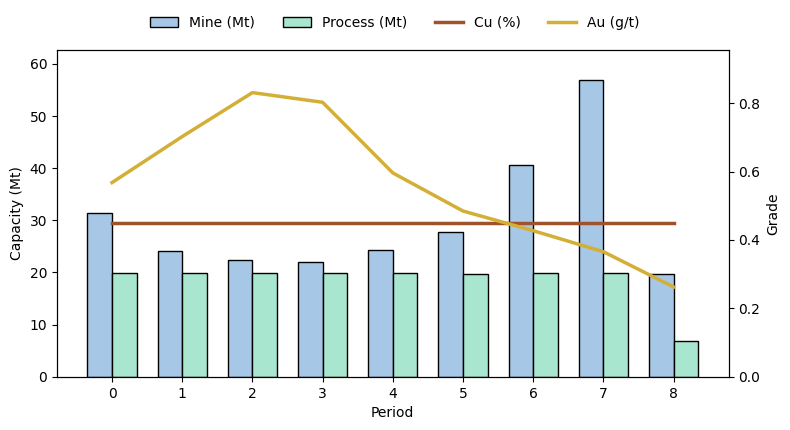

In [20]:
df=blocks.dropna(subset=["period"]).copy()  # extracted

summary=(df.assign(w_proc=df.tonn*df.destination, cu_proc=lambda d:d.cu*d.w_proc, au_proc=lambda d:d.au*d.w_proc)
           .groupby("period",as_index=False)
           .agg(ton_mine=("tonn","sum"), ton_plant=("w_proc","sum"), cu_metal=("cu_proc","sum"), au_metal=("au_proc","sum")))

summary[["cu_grade","au_grade"]]=summary[["cu_metal","au_metal"]].div(summary["ton_plant"],axis=0).fillna(0)

x=np.arange(len(summary)); w=0.35
fig,ax1=plt.subplots(figsize=(8,4))

ax1.bar(x-w/2,summary.ton_mine/1e6,w,label="Mine (Mt)",color="#A7C7E7",edgecolor="black"); ax1.bar(x+w/2,summary.ton_plant/1e6,w,label="Process (Mt)",color="#A8E6CF",edgecolor="black")
ax1.set(xlabel="Period",ylabel="Capacity (Mt)",xticks=x,xticklabels=summary.period.astype(int),ylim=(0,1.1*max(summary.ton_mine.max(),summary.ton_plant.max())/1e6))

ax2=ax1.twinx()
ax2.plot(x,summary.cu_grade,color="#A0522D",lw=2.5,label="Cu (%)"); ax2.plot(x,summary.au_grade,color="#D4AF37",lw=2.5,label="Au (g/t)")
ax2.set(ylabel="Grade",ylim=(0,1.15*max(summary.cu_grade.max(),summary.au_grade.max())))

ax1.patch.set_visible(False)

h,l=zip(*[ax.get_legend_handles_labels() for ax in (ax1,ax2)]); h=sum(h,[]); l=sum(l,[])
fig.legend(h,l,loc="upper center",ncol=4,bbox_to_anchor=(0.5,1.08),frameon=False)

plt.tight_layout(); fig.savefig("marvin_blend_results.png",dpi=300,bbox_inches="tight",facecolor="white"); plt.show()